In [1]:
# =============================================================================
# PROJET : ANALYSE & PRÉVISION DES RECETTES FISCALES GENEVOISES
# Notebook : 04b_walkforward.ipynb
# Auteur   : Frat DAG
# Date     : Avril 2026
# Version  : 2.0 — approche inductive (traduction Python du script R)
# =============================================================================
# CE QU'ON SAIT APRÈS LES NOTEBOOKS 03 ET 04 :
#   - Modèle retenu : ARIMAX (RMSE training=267M)
#   - Les modèles ont été évalués sur données d'entraînement uniquement
#   - Ce notebook corrige cette lacune via validation walk-forward
#
# OBJECTIF :
#   - Valider les 4 modèles sur données non vues (2017-2024)
#   - Comparer les RMSE walk-forward sur base équitable
#   - Confirmer les conclusions du notebook 03
#
# NOTE HONNÊTETÉ :
#   Ce script n'était pas prévu initialement — on s'est rendu compte
#   en fin de projet que la validation sur données d'entraînement
#   n'est pas suffisante. Cette lacune a été corrigée ici.
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Dossiers
for dossier in ['../data', '../figures']:
    os.makedirs(dossier, exist_ok=True)

# Chargement données
df = pd.read_csv('../data/df_fiscal.csv')

print(f"✓ Données chargées : {len(df)} observations")
print(f"  Période : {df['annee'].min()}–{df['annee'].max()}")
print(f"\nPRINCIPE WALK-FORWARD :")
print(f"  Train sur 2007:(t-1) → Prédit t → Avance d'un an")
print(f"  Répété pour t = 2017 à 2024")
print(f"  Chaque modèle voit exactement les mêmes données → comparaison équitable")

✓ Données chargées : 18 observations
  Période : 2007–2024

PRINCIPE WALK-FORWARD :
  Train sur 2007:(t-1) → Prédit t → Avance d'un an
  Répété pour t = 2017 à 2024
  Chaque modèle voit exactement les mêmes données → comparaison équitable


In [2]:
# =============================================================================
# 2. WALK-FORWARD — 4 MODÈLES
# =============================================================================

print("=" * 60)
print("WALK-FORWARD — EXPANDING WINDOW 2017–2024")
print("=" * 60)

annees_test = range(2017, 2025)
resultats   = []

for annee in annees_test:
    # Données d'entraînement : tout jusqu'à t-1
    train = df[df['annee'] < annee].copy()
    reel  = df.loc[df['annee'] == annee, 'total'].values[0]
    ts_train = train['total'].values

    # --- ARIMA ---
    try:
        m_arima = ARIMA(ts_train, order=(0,1,0), trend='t').fit()
        pred_arima = m_arima.forecast(steps=1)[0]
    except:
        pred_arima = np.nan

    # --- ETS ---
    try:
        m_ets = ExponentialSmoothing(
            ts_train, trend=None, seasonal=None,
            initialization_method='estimated'
        ).fit(optimized=True)
        pred_ets = m_ets.forecast(1)[0]
    except:
        pred_ets = np.nan

    # --- ARIMAX ---
    # Non estimable avant 2023 : dummy_rffa = 0 sur tout le training
    # et le test pour 2017-2022
    dummy_train = train['dummy_rffa'].values.reshape(-1, 1)
    dummy_test  = np.array([[1 if annee >= 2022 else 0]])

    if annee >= 2023 and dummy_train.sum() > 0:
        try:
            m_arimax = ARIMA(ts_train, order=(0,1,0),
                            trend='t', exog=dummy_train).fit()
            pred_arimax = m_arimax.forecast(steps=1, exog=dummy_test)[0]
        except:
            pred_arimax = np.nan
    else:
        pred_arimax = np.nan

    # --- Random Forest ---
    df_ml = df.copy()
    df_ml['total_lag1']  = df_ml['total'].shift(1)
    df_ml['total_lag2']  = df_ml['total'].shift(2)
    df_ml['ben_pm_lag1'] = df_ml['ben_pm'].shift(1)
    df_ml['ifd_lag1']    = df_ml['ifd'].shift(1)
    df_ml['saron_lag1']  = df_ml['saron'].shift(1)
    df_ml['ipc_lag1']    = df_ml['ipc'].shift(1)
    df_ml['trend']       = np.arange(1, len(df_ml)+1)

    features = ['total_lag1', 'total_lag2', 'ben_pm_lag1',
                'ifd_lag1', 'saron_lag1', 'ipc_lag1',
                'trend', 'dummy_rffa']

    df_ml_clean = df_ml.dropna(subset=features + ['total'])
    train_rf    = df_ml_clean[df_ml_clean['annee'] < annee]
    test_rf     = df_ml_clean[df_ml_clean['annee'] == annee]

    if len(train_rf) >= 5 and len(test_rf) > 0:
        try:
            np.random.seed(42)
            rf = RandomForestRegressor(
                n_estimators=1000, max_features=3,
                min_samples_leaf=3, random_state=42
            )
            rf.fit(train_rf[features], train_rf['total'])
            pred_rf = rf.predict(test_rf[features])[0]
        except:
            pred_rf = np.nan
    else:
        pred_rf = np.nan

    resultats.append({
        'annee'       : annee,
        'realise'     : reel,
        'pred_arima'  : pred_arima,
        'pred_ets'    : pred_ets,
        'pred_arimax' : pred_arimax,
        'pred_rf'     : pred_rf
    })

df_res = pd.DataFrame(resultats)

# Tableau prédictions vs réalisations
print("\n=== PRÉDICTIONS VS RÉALISATIONS ===")
print(f"{'Année':>6} {'Réalisé':>8} {'ARIMA':>8} "
      f"{'ETS':>8} {'ARIMAX':>8} {'RF':>8}")
print("-" * 55)
for _, row in df_res.iterrows():
    arimax_str = f"{row['pred_arimax']:>8,.0f}" \
                 if not np.isnan(row['pred_arimax']) else "     n/a"
    rf_str = f"{row['pred_rf']:>8,.0f}" \
             if not np.isnan(row['pred_rf']) else "     n/a"
    print(f"{row['annee']:>6.0f} {row['realise']:>8,.0f} "
          f"{row['pred_arima']:>8,.0f} {row['pred_ets']:>8,.0f} "
          f"{arimax_str} {rf_str}")

# RMSE walk-forward — toutes années
print("\n=== RMSE WALK-FORWARD — TOUTES ANNÉES (2017–2024) ===")
for modele, col in [('ARIMA', 'pred_arima'), ('ETS', 'pred_ets'),
                     ('ARIMAX', 'pred_arimax'), ('RF', 'pred_rf')]:
    df_valid = df_res.dropna(subset=[col])
    if len(df_valid) > 0:
        rmse = np.sqrt(mean_squared_error(
            df_valid['realise'], df_valid[col]))
        print(f"  {modele:10s} : {rmse:.0f}M "
              f"(N={len(df_valid)})")

# RMSE hors RFFA (2017-2021)
print("\n=== RMSE WALK-FORWARD — HORS RFFA (2017–2021) ===")
df_hors = df_res[df_res['annee'] <= 2021]
for modele, col in [('ARIMA', 'pred_arima'), ('ETS', 'pred_ets'),
                     ('RF', 'pred_rf')]:
    df_valid = df_hors.dropna(subset=[col])
    if len(df_valid) > 0:
        rmse = np.sqrt(mean_squared_error(
            df_valid['realise'], df_valid[col]))
        print(f"  {modele:10s} : {rmse:.0f}M")
print(f"  {'ARIMAX':10s} : exclu (non estimable avant 2023)")

print("\n# DÉCISION FINALE :")
print("# ARIMA = meilleur en conditions normales (hors RFFA)")
print("# ARIMAX = meilleur sur ensemble de la période")
print("# ARIMAX retenu pour prévisions 2025-2027")

WALK-FORWARD — EXPANDING WINDOW 2017–2024

=== PRÉDICTIONS VS RÉALISATIONS ===
 Année  Réalisé    ARIMA      ETS   ARIMAX       RF
-------------------------------------------------------
  2017    6,641    6,590    6,496      n/a    6,351
  2018    7,173    6,708    6,585      n/a    6,443
  2019    7,363    7,282    7,036      n/a    6,620
  2020    7,454    7,479    7,363      n/a    6,792
  2021    7,871    7,568    7,454      n/a    6,841
  2022    9,269    8,007    7,871      n/a    7,229
  2023    9,734    9,489    9,269    9,405    7,637
  2024    9,269    9,969    9,734    9,892    8,216

=== RMSE WALK-FORWARD — TOUTES ANNÉES (2017–2024) ===
  ARIMA      : 555M (N=8)
  ETS        : 617M (N=8)
  ARIMAX     : 498M (N=2)
  RF         : 1242M (N=8)

=== RMSE WALK-FORWARD — HORS RFFA (2017–2021) ===
  ARIMA      : 252M
  ETS        : 362M
  RF         : 730M
  ARIMAX     : exclu (non estimable avant 2023)

# DÉCISION FINALE :
# ARIMA = meilleur en conditions normales (hors RFFA)
# A

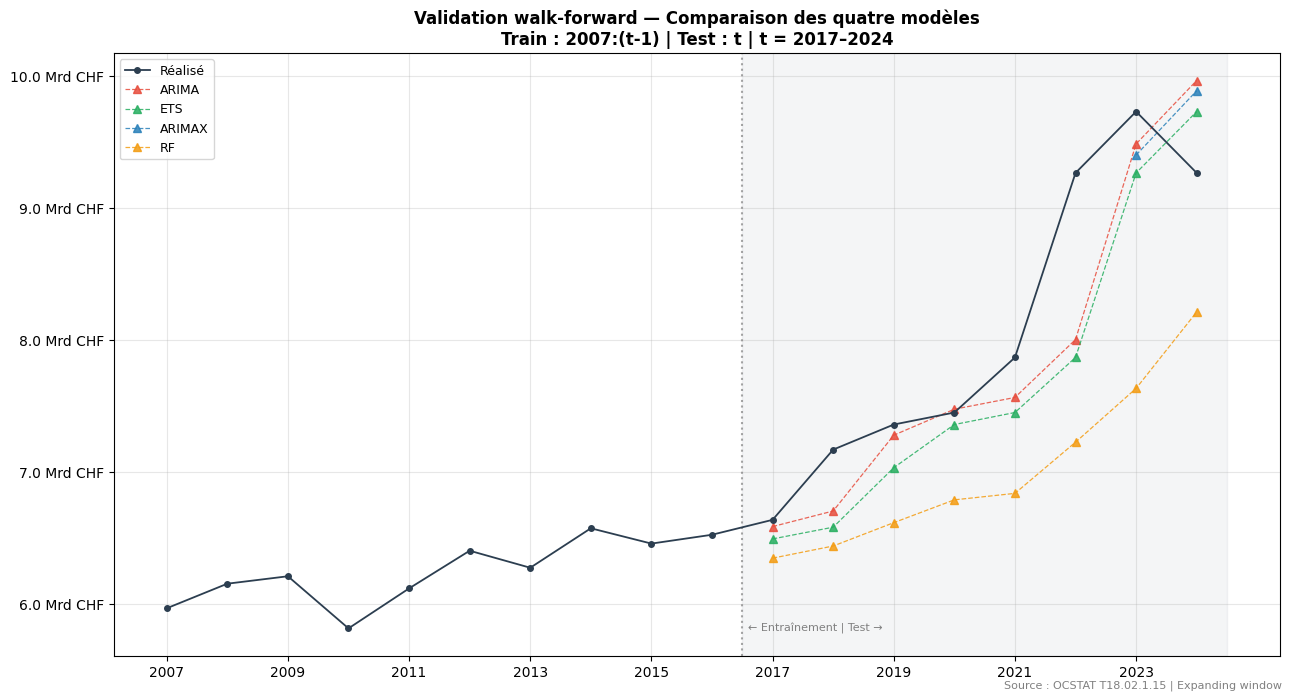

✓ Graphique walk-forward sauvegardé


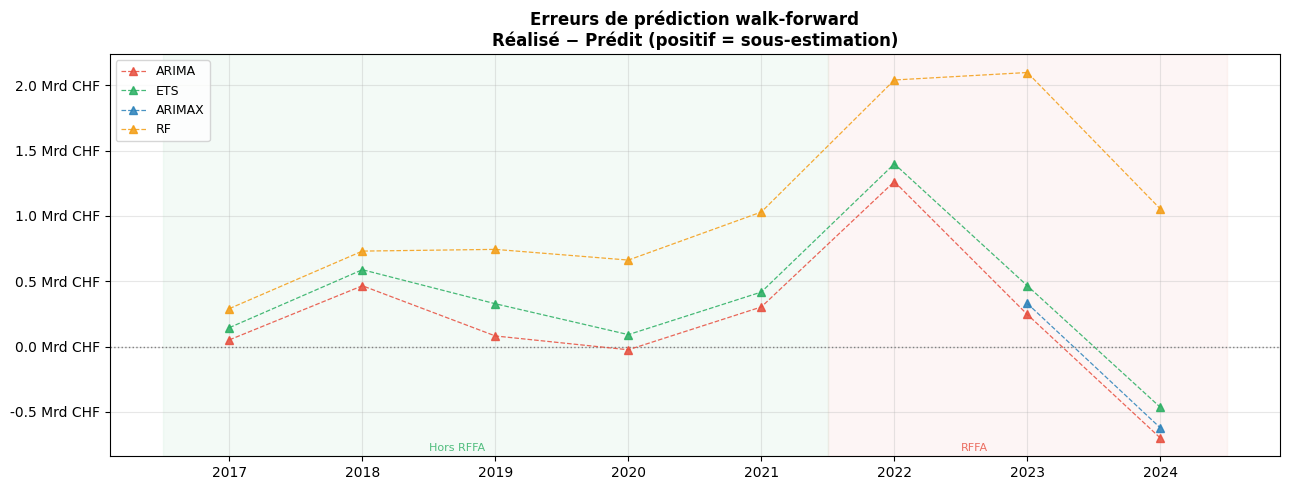

✓ Graphique erreurs sauvegardé

✓ Résultats walk-forward sauvegardés

=== NOTEBOOK 04b TERMINÉ ===
Pipeline Python complet — 5 notebooks exécutés avec succès


In [3]:
# =============================================================================
# 3. GRAPHIQUES
# =============================================================================

COULEURS = ['#2C3E50', '#E74C3C', '#2980B9', '#27AE60', '#F39C12']

# --- Graphique 1 : Walk-forward prédictions vs réalisations ---
fig, ax = plt.subplots(figsize=(13, 7))

# Série historique complète
ax.plot(df['annee'], df['total']/1000,
        color=COULEURS[0], linewidth=1.3,
        marker='o', markersize=4, label='Réalisé', zorder=5)

# Prédictions walk-forward
modeles_wf = {
    'ARIMA'  : (COULEURS[1], 'pred_arima'),
    'ETS'    : (COULEURS[3], 'pred_ets'),
    'ARIMAX' : (COULEURS[2], 'pred_arimax'),
    'RF'     : (COULEURS[4], 'pred_rf')
}

for label, (couleur, col) in modeles_wf.items():
    df_plot = df_res.dropna(subset=[col])
    ax.plot(df_plot['annee'], df_plot[col]/1000,
            color=couleur, linewidth=0.9,
            linestyle='dashed', marker='^',
            markersize=6, label=label, alpha=0.85)

# Zone walk-forward
ax.axvspan(2016.5, 2024.5, alpha=0.05,
           color=COULEURS[0], label='_nolegend_')
ax.axvline(x=2016.5, linestyle='dotted',
           color='grey', alpha=0.7)
ax.annotate('← Entraînement | Test →',
            xy=(2016.6, 5.8), fontsize=8, color='grey')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.1f} Mrd CHF"))
ax.set_xticks(range(2007, 2025, 2))
ax.set_title("Validation walk-forward — Comparaison des quatre modèles\n"
             "Train : 2007:(t-1) | Test : t | t = 2017–2024",
             fontweight='bold', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
fig.text(0.99, 0.01,
         "Source : OCSTAT T18.02.1.15 | Expanding window",
         ha='right', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('../figures/04b_walkforward_py.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique walk-forward sauvegardé")

# --- Graphique 2 : Erreurs de prédiction ---
fig, ax = plt.subplots(figsize=(13, 5))

ax.axhline(y=0, color='grey', linestyle='dotted', linewidth=1)
ax.axvspan(2016.5, 2021.5, alpha=0.05,
           color=COULEURS[3], label='_nolegend_')
ax.axvspan(2021.5, 2024.5, alpha=0.05,
           color=COULEURS[1], label='_nolegend_')

for label, (couleur, col) in modeles_wf.items():
    df_plot = df_res.dropna(subset=[col])
    erreurs = df_plot['realise'] - df_plot[col]
    ax.plot(df_plot['annee'], erreurs/1000,
            color=couleur, linewidth=0.9,
            linestyle='dashed', marker='^',
            markersize=6, label=label, alpha=0.85)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.1f} Mrd CHF"))
ax.set_xticks(range(2017, 2025))
ax.set_title("Erreurs de prédiction walk-forward\n"
             "Réalisé − Prédit (positif = sous-estimation)",
             fontweight='bold', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# Annotations zones
ax.annotate('Hors RFFA', xy=(2018.5, -0.8),
            fontsize=8, color=COULEURS[3], alpha=0.8)
ax.annotate('RFFA', xy=(2022.5, -0.8),
            fontsize=8, color=COULEURS[1], alpha=0.8)

plt.tight_layout()
plt.savefig('../figures/04b_erreurs_walkforward_py.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique erreurs sauvegardé")

# Sauvegarde résultats
df_res.to_csv('../data/walkforward_resultats.csv', index=False)
print("\n✓ Résultats walk-forward sauvegardés")
print("\n=== NOTEBOOK 04b TERMINÉ ===")
print("Pipeline Python complet — 5 notebooks exécutés avec succès")